In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from typing import Literal

In [2]:
# Create State
class ContentState(TypedDict):
    text: str
    score: float #0.0 to 10.0
    category: str
    message: str

In [3]:
def analyze_content(state: ContentState) -> dict:
    """Simulate content analysis with a simple scoring system."""
    print(f"🔍 Analyzing content: '{state['text'][:50]}...'")
    
    # Simple scoring: count "good" vs "bad" keywords
    text_lower = state["text"].lower()
    good_words = ["fine", "excellent", "amazing", "helpful", "good"]
    bad_words = ["spam", "scam", "fake", "terrible", "hate"]
    
    good_count = sum(word in text_lower for word in good_words)
    bad_count = sum(word in text_lower for word in bad_words)
    
    # Calculate score
    if good_count + bad_count == 0:
        score = 0.5  # Neutral
    else:
        score = good_count / (good_count + bad_count)
    
    print(f"📊 Content score: {score:.2f}")
    return {"score": score}

# Routing function: Decides which path to take
def route_content(state: ContentState) -> Literal["approve", "reject", "review"]:
    """Route content based on score."""
    score = state["score"]
    
    if score >= 0.7:
        print("✅ Routing to APPROVE")
        return "approve"
    elif score < 0.3:
        print("❌ Routing to REJECT")
        return "reject"
    else:
        print("⚠️  Routing to REVIEW")
        return "review"

# Terminal nodes for each path
def approve_content(state: ContentState) -> dict:
    """Approve the content."""
    print("✅ Content APPROVED")
    return {
        "category": "approved",
        "message": "Content approved for publication"
    }

def reject_content(state: ContentState) -> dict:
    """Reject the content."""
    print("❌ Content REJECTED")
    return {
        "category": "rejected",
        "message": "Content does not meet quality standards"
    }

def review_content(state: ContentState) -> dict:
    """Flag for manual review."""
    print("⚠️  Content flagged for REVIEW")
    return {
        "category": "review",
        "message": "Content requires manual review"
    }

In [5]:
# Build the graph
graph = StateGraph(ContentState)

# Add nodes
graph.add_node("analyze", analyze_content)
graph.add_node("approve", approve_content)
graph.add_node("reject", reject_content)
graph.add_node("review", review_content)

# Add edges
graph.add_edge(START, "analyze")

# add conditional edge

# CONDITIONAL EDGE: The key new concept!
graph.add_conditional_edges(
    "analyze",           # Source node
    route_content,       # Routing function
    # The routing function returns one of these node names:
    # - "approve", "reject", or "review"
)

graph.add_edge("approve", END)
graph.add_edge("reject", END)
graph.add_edge("review", END)

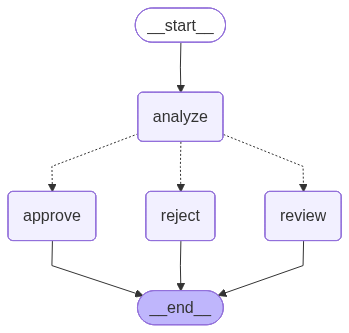

In [6]:
app = graph.compile()
app

In [8]:
# Execute the graph
# Test 1: Positive content (should be approved)
print("=" * 60)
print("TEST 1: Positive Content")
print("=" * 60)

result1 = app.invoke({
    "text": "This is a great and amazing product! Excellent quality and very helpful.",
    "score": 0.0,
    "category": "",
    "message": ""
})

print(f"\n📝 Result: {result1['category'].upper()}")
print(f"💬 Message: {result1['message']}\n")

TEST 1: Positive Content
🔍 Analyzing content: 'This is a great and amazing product! Excellent qua...'
📊 Content score: 1.00
✅ Routing to APPROVE
✅ Content APPROVED

📝 Result: APPROVED
💬 Message: Content approved for publication



In [9]:
# Test 2: Negative content (should be rejected)
print("=" * 60)
print("TEST 2: Negative Content")
print("=" * 60)

result2 = app.invoke({
    "text": "This is spam! Terrible scam, fake product. I hate it.",
    "score": 0.0,
    "category": "",
    "message": ""
})

print(f"\n📝 Result: {result2['category'].upper()}")
print(f"💬 Message: {result2['message']}\n")

TEST 2: Negative Content
🔍 Analyzing content: 'This is spam! Terrible scam, fake product. I hate ...'
📊 Content score: 0.00
❌ Routing to REJECT
❌ Content REJECTED

📝 Result: REJECTED
💬 Message: Content does not meet quality standards

